In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df=pd.read_csv('store_customers.csv')

In [4]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
...,...,...,...,...,...
995,1995,M,80.0,133.3,1.0
996,1996,M,44.0,82.6,40.0
997,1997,F,46.0,67.7,26.0
998,1998,F,28.0,45.7,59.0


In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [8]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].median())
df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].median())

In [14]:
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [18]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

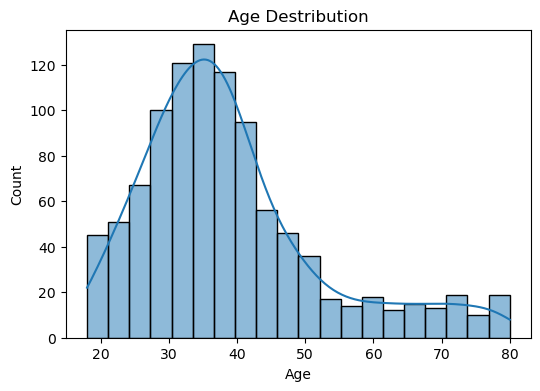

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],bins=20, kde=True,)
plt.title("Age Destribution")
plt.show()

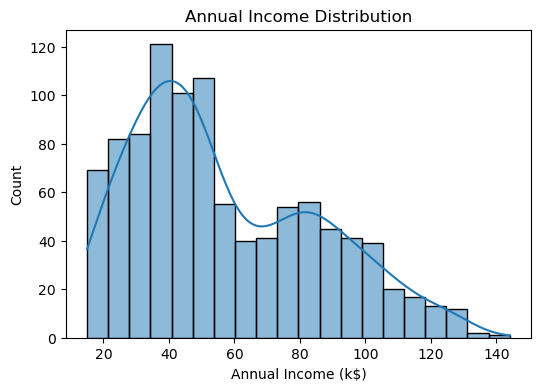

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)
plt.title("Annual Income Distribution")
plt.show()

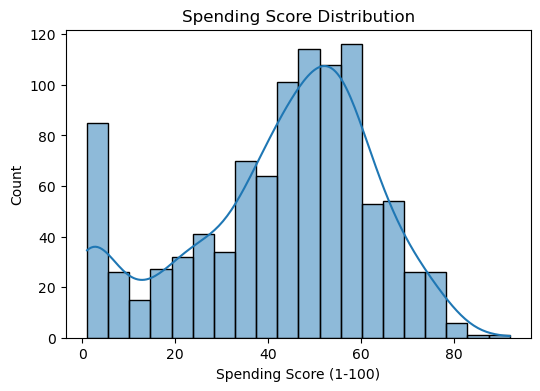

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)
plt.title("Spending Score Distribution")
plt.show()

In [23]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

In [24]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


In [25]:
scaler=StandardScaler()
X_Scaled=scaler.fit_transform(X)

In [31]:
wcss=[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_Scaled)
    wcss.append(kmeans.inertia_)

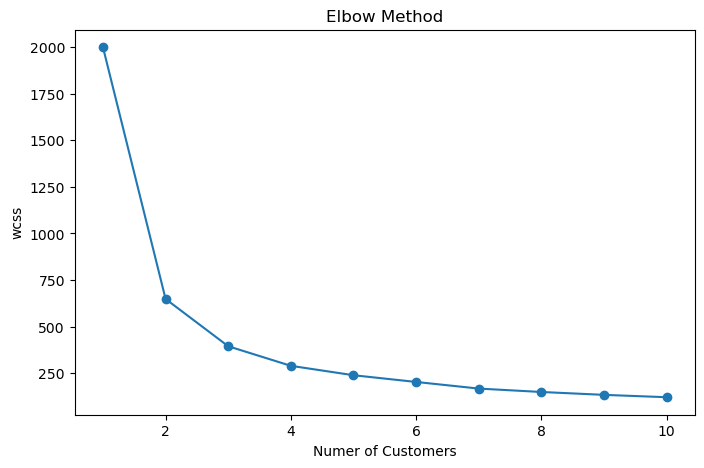

In [32]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss , marker='o')
plt.xlabel("Numer of Customers")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

In [36]:
kmeans=KMeans(n_clusters=5,random_state=42,n_init=10)
df["Cluster"]=kmeans.fit_predict(X_Scaled)

In [37]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,0
1,1001,M,34.0,48.4,37.0,0
2,1002,F,40.0,70.5,26.0,3
3,1003,F,47.0,81.1,30.0,3
4,1004,F,33.0,42.1,58.0,4


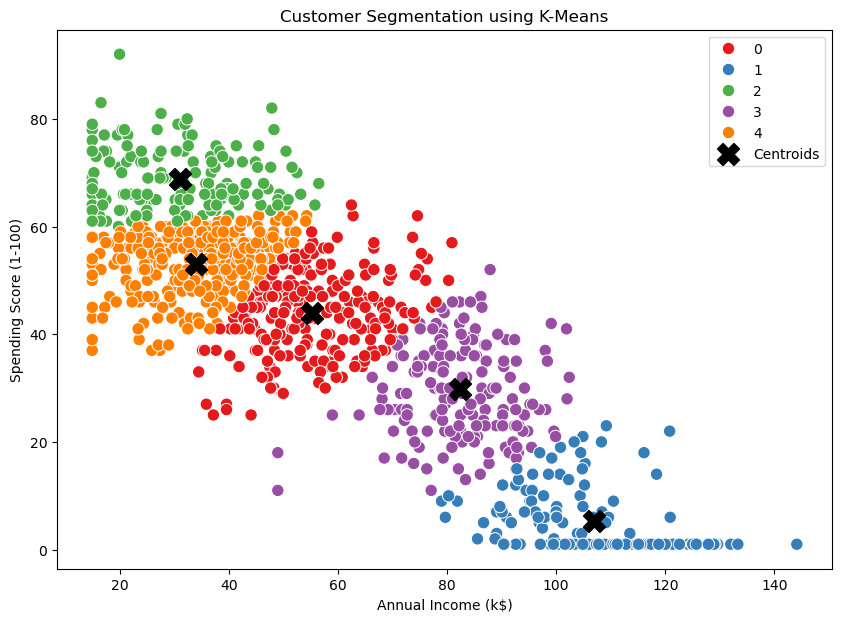

In [39]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=80
)
plt.scatter(
    scaler.inverse_transform(kmeans.cluster_centers_)[:,0],
    scaler.inverse_transform(kmeans.cluster_centers_)[:,1],
    color="black",
    marker="X",
    s=250,
    label="Centroids"
)
plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

In [40]:
df.groupby("Cluster")[["Annual Income (k$)","Spending Score (1-100)","Age"]].mean()

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.338494,43.933054,37.016736
1,106.905147,5.257353,65.080882
2,31.031788,68.854305,28.682119
3,82.477273,29.710227,45.823864
4,34.059396,53.124161,29.610738


In [41]:
plt.savefig("customer_segments.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

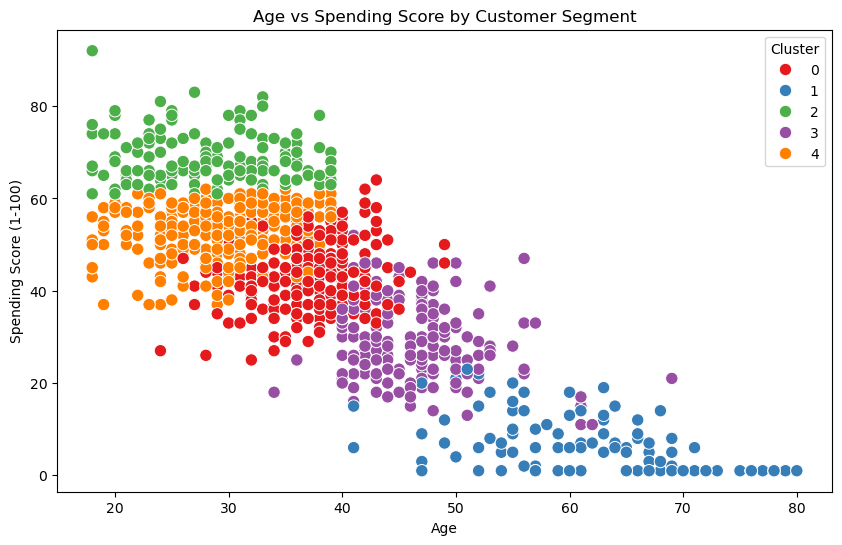

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Age vs Spending Score by Customer Segment")
plt.show()